# Analysing Student–LLM Collaboration Quality

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE

In [2]:
convs = pd.read_csv("alma_conversations_sample.csv")
convs.head()

,student_id,student_request,llm_response,timestamp
0,leaps_user105,"can you explain what the authors mean by ""stud...","In text B, the authors are referring to the fa...",33:45.5
1,leaps_user105,explain the unfair results of Kolkman further,"In the text, Kolkman argues that the reliance ...",37:37.9
2,leaps_user108,Predictive modelling is based on the assumptio...,Predictive modelling in education uses past da...,15:02.6
3,leaps_user108,write me an introduction including what is pre...,Predictive modelling is a powerful technique t...,18:26.9
4,leaps_user108,"Nowadays, predictive modelling is emerging as ...","Nowadays, predictive modelling is emerging as ...",23:49.7


In [3]:
essays = pd.read_csv("alma_essays_sample.csv")
essays.head()

,student_id,essay
0,leaps_user105,Predictive modelling is a technique that has t...
1,leaps_user108,Predictive modelling is a powerful technique t...
2,leaps_user111,Predictive modelling in education has emerged ...
3,leaps_user112,Predicting modeling in education is based on c...
4,leaps_user114,Predictive modelling is based on the assumptio...


In [4]:
print(convs.loc[19, 'student_request'])
#print()
#print(convs.loc[19, 'llm_response'])
#print()
#print(convs.loc[4, 'last25'])

Predictive modelling is a tool that can be used to understand and identify which students may drop out of university, or any courses in general. The basis of predictive modelling is that past situations and behaviors can be indicators of drop-out behaviour. Therefore, these models are trained on past students drop out behavior, to predict the likelyhood of future students' dropping out. This can be beneficial to students so that teachers and administrators can offer extra help to those who may be struggling. 

However, predictive modeling may cause harm if the training data of past students is not sufficient. Namely, if the training data is limited to one behavior some students can fall through the cracks. General data which does not differentiate between the class context can  The training data can also amplify stereotypes if the indicators heavily rely on demographic data. Furthermore, relying on students digital footprint in predicting their success might not be consistently accurat

## Feature Engineering

### 1) Descriptives of requests

In [6]:
df = convs.copy()

#Parse timestamp (mm:ss.s --> seconds)
def parse_time(t):
    minutes, seconds = t.split(':')
    return float(minutes) * 60 + float(seconds)

df['timestamp_sec'] = df['timestamp'].apply(parse_time)

#Sort by student and timestamp
df = df.sort_values(['student_id', 'timestamp_sec'])

#Time differences
df['time_diff_sec'] = df.groupby('student_id')['timestamp_sec'].diff()

#Aggregate 
student_stats = df.groupby('student_id').agg(
    num_requests=('student_request', 'count'),
    session_duration=('timestamp_sec', lambda x: x.max() - x.min())
).reset_index()

#Create request frequency (requests per minute)
student_stats['requests_per_min'] = (
    student_stats['num_requests'] / (student_stats['session_duration'] / 60)
)

# Handle divide-by-zero (if duration = 0)
student_stats['requests_per_min'] = student_stats['requests_per_min'].replace([float('inf')], 0)
#Clean NaNs if any
student_stats = student_stats.fillna(0)

student_stats.head()

,student_id,num_requests,session_duration,requests_per_min
0,leaps_user105,2,232.4,0.516351
1,leaps_user108,9,1969.9,0.274126
2,leaps_user111,4,674.5,0.355819
3,leaps_user112,2,549.5,0.218380
4,leaps_user114,2,308.2,0.389358


### 2) Student requests content

In [7]:
#Define a funcion to get the last n words of a text, handling NaNs
def get_last_n_words(text, n=25):
    if pd.isna(text):
        return ""
    words = str(text).split()
    return ' '.join(words[-n:])

convs['last25'] = convs['student_request'].apply(get_last_n_words)

In [8]:
inquiry_df = convs.groupby('student_id').agg(
    num_requests=('student_request', 'count'),
    requests_last25_list=('last25', list),
    #requests_last25_concat=('last25', lambda x: ' '.join(x))
).reset_index()

inquiry_df.head()

,student_id,num_requests,requests_last25_list
0,leaps_user105,2,"[can you explain what the authors mean by ""stu..."
1,leaps_user108,9,"[responsibly, it can help make education faire..."
2,leaps_user111,4,[it must be used responsibly (Brooks & Thompso...
3,leaps_user112,2,"[in the classroom (Gašević et al., 2016). can ..."
4,leaps_user114,2,[that data that describes past events can be u...


In [9]:
#Define inquiry function
inquiry_verbs = [
    'explain', 'clarify', 'summarize', 'elaborate',
    'describe', 'analyze', 'interpret', 'expand'
]

confirmation_patterns = [
    'is this', 'does this', 'can you check',
    'what do you think', 'is anything missing'
]

def is_inquiry(text):
    if pd.isna(text):
        return 0
    
    text = text.lower()
    
    # question mark
    if '?' in text:
        return 1
    
    # inquiry verbs
    if any(word in text for word in inquiry_verbs):
        return 1
    
    # confirmation patterns
    if any(phrase in text for phrase in confirmation_patterns):
        return 1
    
    return 0

In [10]:
#Apply "is_inquiry" at the request level (that's why it's applied to convs)
convs['is_inquiry'] = convs['last25'].apply(is_inquiry)

#Then aggregate to student level
inquiry_stats = convs.groupby('student_id').agg(
    inquiry_count=('is_inquiry', 'sum')
).reset_index()

#Add to df_inquiry
inquiry_df = inquiry_df.merge(inquiry_stats, on='student_id')
inquiry_df.head()

,student_id,num_requests,requests_last25_list,inquiry_count
0,leaps_user105,2,"[can you explain what the authors mean by ""stu...",2
1,leaps_user108,9,"[responsibly, it can help make education faire...",2
2,leaps_user111,4,[it must be used responsibly (Brooks & Thompso...,0
3,leaps_user112,2,"[in the classroom (Gašević et al., 2016). can ...",2
4,leaps_user114,2,[that data that describes past events can be u...,1


In [11]:
inquiry_df['inquiry_ratio'] = (inquiry_df['inquiry_count'] / inquiry_df['num_requests']).round(2)
inquiry_df.head()

,student_id,num_requests,requests_last25_list,inquiry_count,inquiry_ratio
0,leaps_user105,2,"[can you explain what the authors mean by ""stu...",2,1.00
1,leaps_user108,9,"[responsibly, it can help make education faire...",2,0.22
2,leaps_user111,4,[it must be used responsibly (Brooks & Thompso...,0,0.00
3,leaps_user112,2,"[in the classroom (Gašević et al., 2016). can ...",2,1.00
4,leaps_user114,2,[that data that describes past events can be u...,1,0.50


### 3) LLM responses and final essay

In [12]:
# Group and concatenate all LLM responses per student
llm_texts = convs.groupby('student_id')['llm_response'].apply(lambda x: ' '.join(x)).reset_index()

llm_texts.rename(columns={'llm_response': 'llm_combined'}, inplace=True)

# Merge with essay dataset
reliance_df = pd.merge(llm_texts, essays, on='student_id')

reliance_df.head()

,student_id,llm_combined,essay
0,leaps_user105,"In text B, the authors are referring to the fa...",Predictive modelling is a technique that has t...
1,leaps_user108,Predictive modelling in education uses past da...,Predictive modelling is a powerful technique t...
2,leaps_user111,The main argument of Text A is that predictive...,Predictive modelling in education has emerged ...
3,leaps_user112,"I'm sorry, but I do not have access to specifi...",Predicting modeling in education is based on c...
4,leaps_user114,"Yes, this statement is true. Predictive modeli...",Predictive modelling is based on the assumptio...


In [13]:
similarities = []

for i, row in reliance_df.iterrows():
    texts = [row['llm_combined'], row['essay']]
    
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(texts)
    
    sim = round(cosine_similarity(tfidf_matrix[0], tfidf_matrix[1])[0][0], 2)
    similarities.append(sim)

reliance_df['similarity'] = similarities

reliance_df[['student_id', 'similarity']].head()

,student_id,similarity
0,leaps_user105,0.45
1,leaps_user108,0.94
2,leaps_user111,0.97
3,leaps_user112,0.61
4,leaps_user114,0.43


## Clustering

In [14]:
#Creating a feature_df, including the request frequency, inquiry ratio, and reliance similarity for each student
feature_df = student_stats[['student_id', 'requests_per_min']].merge(
    inquiry_df[['student_id', 'inquiry_ratio']],
    on='student_id'
).merge(
    reliance_df[['student_id', 'similarity']],
    on='student_id'
)

feature_df.head()

,student_id,requests_per_min,inquiry_ratio,similarity
0,leaps_user105,0.516351,1.00,0.45
1,leaps_user108,0.274126,0.22,0.94
2,leaps_user111,0.355819,0.00,0.97
3,leaps_user112,0.218380,1.00,0.61
4,leaps_user114,0.389358,0.50,0.43


### Checking correlation between features
It is expected to have some correlation, as it can help reveal meaningful cluster structures. But gotta make sure that they are not dependent on each other (to the point that they basically carry the same information)

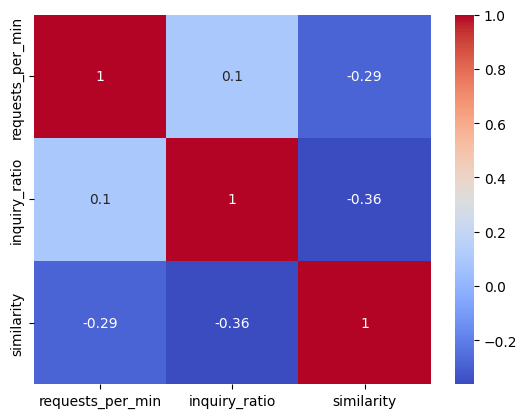

In [15]:
# Compute correlation matrix
corr_matrix = feature_df[['requests_per_min', 'inquiry_ratio', 'similarity']].corr()

# Quick heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

looks good. Conventionally falls under "weak correlation" category, that is right after "neglible correlation" (Schober et al., 2018).

Schober, P., Boer, C., & Schwarte, L. A. (2018). Correlation coefficients: appropriate use and interpretation. Anesthesia & analgesia, 126(5), 1763-1768.

### Choosing number of clusters

In [16]:
#Scaling the features so requests_per_min doesn't dominate the others
scaler = StandardScaler()
feature_scaled = scaler.fit_transform(feature_df[['requests_per_min', 'inquiry_ratio', 'similarity']])

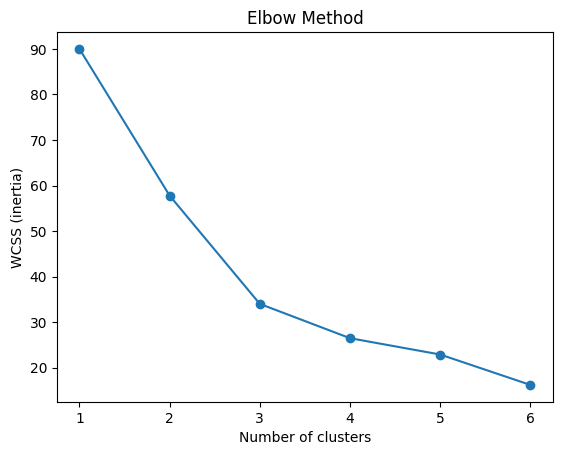

In [17]:
#Elbow method to find optimal k
wcss = []
for k in range(1, 7):  # 1–6 clusters for 30 students is reasonable
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(feature_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 7), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (inertia)')
plt.title('Elbow Method')
plt.show()

In [18]:
#Silhouette scores for k=2 to 5
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(feature_scaled)
    score = silhouette_score(feature_scaled, labels)
    print(f'k={k}, silhouette={score:.2f}')

k=2, silhouette=0.46
k=3, silhouette=0.51
k=4, silhouette=0.49
k=5, silhouette=0.45


Taken together, silhouette scores and elbow method suggests 3 clusters could correspond to meaningful patterns of collaboration as indicated by interaction (number of requests), inquiry and reliance.

In [19]:
# Run K-means with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
feature_df['cluster'] = kmeans.fit_predict(feature_scaled)

# Inspect cluster centers (in scaled space)
print("Cluster centers (scaled features):")
print(kmeans.cluster_centers_)

# Map cluster centers back to original feature ranges for interpretability
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=['requests_per_min', 'inquiry_ratio', 'similarity'])
print("\nCluster centers (original feature values):")
print(centers_df)

# Quick view of student assignments
feature_df[['student_id', 'cluster']].sort_values('cluster').head()

Cluster centers (scaled features):
[[-0.45706471 -0.38248508  0.68849647]
 [ 1.57658123  0.17702285 -0.63149676]
 [-0.56178078  1.12911431 -1.59449183]]

Cluster centers (original feature values):
   requests_per_min  inquiry_ratio  similarity
0          0.449781       0.194444    0.893333
1          2.233627       0.357143    0.600000
2          0.357928       0.634000    0.386000


,student_id,cluster
1,leaps_user108,0
2,leaps_user111,0
6,leaps_user117,0
7,leaps_user127,0
11,leaps_user45,0


Using k=3 clusters, which was supported by both the elbow method and the highest silhouette score (0.51, indicating moderately well-separated clusters*), students were grouped according to their interaction intensity, inquiry-driven engagement, and reliance on LLMs. The cluster centers provide a clear profile of each group, enabling conceptual interpretation in terms of collaboration quality.

*Bagirov, A. M., Aliguliyev, R. M., & Sultanova, N. (2023). Finding compact and well-separated clusters: Clustering using silhouette coefficients. Pattern Recognition, 135, 109144.

### Visualizations

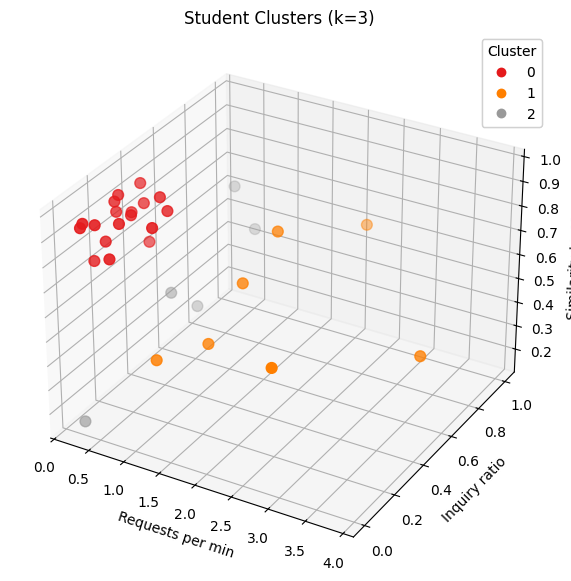

In [20]:
# 3D plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter, colored by cluster
scatter = ax.scatter(
    feature_df['requests_per_min'],
    feature_df['inquiry_ratio'],
    feature_df['similarity'],
    c=feature_df['cluster'],
    cmap='Set1',  # you can choose other colormaps
    s=60
)

# Labels
ax.set_xlabel('Requests per min')
ax.set_ylabel('Inquiry ratio')
ax.set_zlabel('Similarity to essay')

ax.set_title('Student Clusters (k=3)')

# Legend
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)

plt.show()

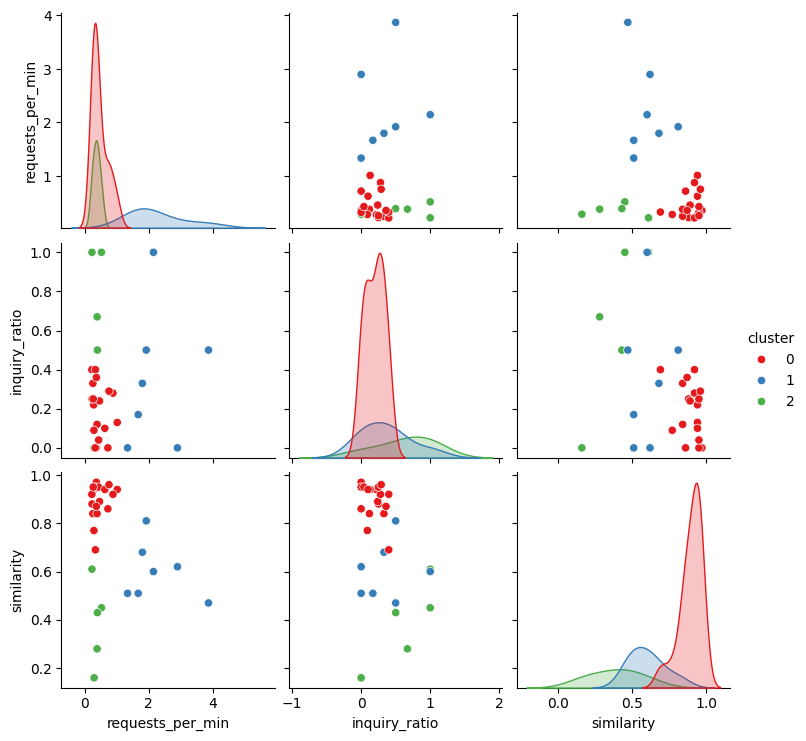

In [21]:
sns.pairplot(
    feature_df,
    vars=['requests_per_min', 'inquiry_ratio', 'similarity'],
    hue='cluster',
    palette='Set1',
    diag_kind='kde' 
)

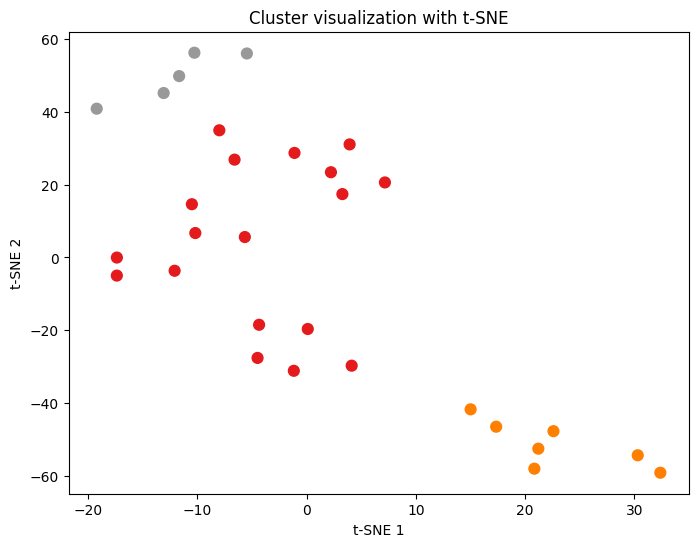

In [22]:
# A t-SNE plot showing that points group together nicely by cluster
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
X_tsne = tsne.fit_transform(feature_df[['requests_per_min', 'inquiry_ratio', 'similarity']])

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=feature_df['cluster'], cmap='Set1', s=60)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Cluster visualization with t-SNE')
plt.show()